In [1]:
import xarray as xr 
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import matplotlib.dates as mdates
import numpy as np 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cmocean as cmo
import matplotlib.dates as mdates
import os 
import xarray as xr 
import datetime
from datetime import datetime, timedelta



def julian_to_datetime(julian_days, seconds_, base_julian=2440000, base_date_str="1968-05-23 00:00:00"):
    # 1. Establish your datum anchor point

    julian_days = np.asarray(julian_days)
    seconds_ = np.asarray(seconds_)
    base_date = np.datetime64(base_date_str)
    days_diff = (julian_days - base_julian) * np.timedelta64(1, 'D')
    seconds = seconds_ * np.timedelta64(1, 'ms')
    dates = base_date + days_diff + seconds
    return dates

def format_date_ax(ax, int=1):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=int))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)
    
ds = xr.open_dataset("hydro.nc", decode_times=False)
print(ds)
nt = len(ds.time) - 1
z = ds.z.values

# ds = ds.isel(time=slice(15, nt))

nt = len(ds.time) - 1

# Load adv data
adv = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/data/usgs/eps_shear_tke.csv", parse_dates=['time'], index_col='time')
adv.dropna(inplace=True, how='all')
print(adv)


<xarray.Dataset> Size: 54MB
Dimensions:  (time: 15120, z: 50)
Coordinates:
  * time     (time) float32 60kB 0.0 195.0 395.0 ... 3.024e+06 3.024e+06
  * z        (z) float32 200B 3.96 3.88 3.8 3.72 3.64 ... 0.28 0.2 0.12 0.04
Data variables:
    U        (time, z) float64 6MB ...
    Kq       (time, z) float64 6MB ...
    Nu       (time, z) float64 6MB ...
    C        (time, z) float64 6MB ...
    Kz       (time, z) float64 6MB ...
    L        (time, z) float64 6MB ...
    Q2       (time, z) float64 6MB ...
    Q2L      (time, z) float64 6MB ...
    N_BV2    (time, z) float64 6MB ...
Attributes:
    title:    testing
Empty DataFrame
Columns: [eps, shear, tke]
Index: []


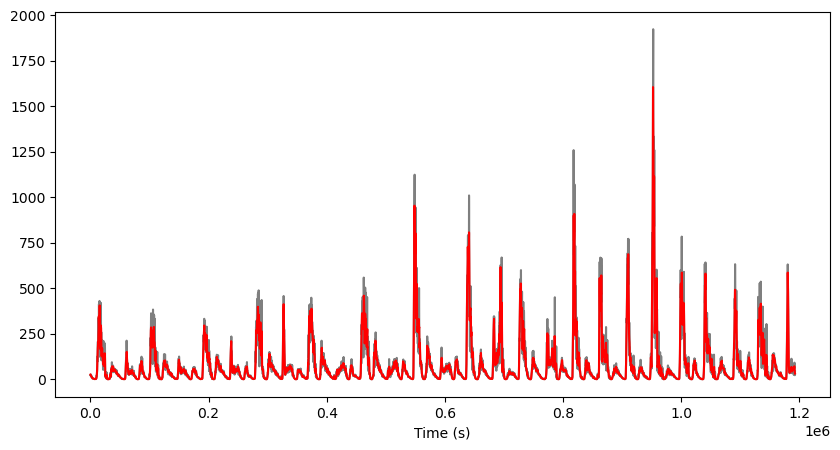

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt


adv = pd.read_csv("processed_adv_data.csv" , parse_dates=['time'])


# fig = plt.figure(figsize=(12, 6))
# ax = plt.gca() 

# ax.plot(pd.to_datetime(adv['time']), adv['smoothed_shear'], label='Shear', color='k', alpha=0.5)
# ax.plot(pd.to_datetime(adv['time']), adv['shear'], label='Shear', color='blue', alpha=0.2)


adv_shear = adv.copy()
adv_shear.dropna(inplace=True, how='any')
adv_shear = adv_shear[['time', 'shear', 'smoothed_shear']]

adv_shear.index = adv_shear.time 

# adv_shear = adv_shear.iloc[0: 280]
# print(adv_shear)
adv_shear = adv_shear.resample('1s').mean()
adv_shear = adv_shear.interpolate(method='linear', limit_direction='both')
adv_shear.reset_index(drop=True, inplace=True)
adv_shear['seconds'] = np.arange(len(adv_shear))
fig = plt.figure(figsize=(10, 5))
ax = plt.gca()
ax.plot(adv_shear.seconds, adv_shear.shear, color='k', alpha=0.5, label="Original shear")
ax.plot(adv_shear.seconds, adv_shear.smoothed_shear, color='r', label="Smoothed shear")
ax.set_xlabel("Time (s)")
adv_shear.to_csv("adv_shear_4_model.csv")

In [3]:
# LISST 

# LISST data 
    # Process_Description: Files were named with a convention that uses a 12- to 15-digit alpha-numeric code. 
    #     The first three characters for this dataset are all 'CSF' for the experiment name; the fourth and fifth positions represent the calendar year in which the data were collected (20, 2020); the sixth, seventh and eighth characters are an alphanumeric code for the platform name (CHT, SC1, etc.); the ninth and tenth characters represent the instrument position on the platform, where 01 is the top-most. Next is a two- or three-character code for the instrument type (vec, Nortek's Acoustic Doppler Velocimeter; alt, EofE Ultrasonics' altimeter; wh, RDInstrument's acoustic doppler current profile current data; pt, RBR's bursting pressure sensor with temperature; ctd, RBR's CTD; Tu, RBR's Virtuoso turbidity logger; ls, Sequoia Scientific's LISST; sig, Nortek's Signature1000 ADCP). There are an additional 2-4 characters for instruments that collect in a bursting pattern to indicate whether the file includes the raw burst data (-b), the statistics of the burst (-s), or the wave data (-wvs). This indicator is omitted if there is no bursting pattern.
    #     Process_Date: 20210301

fn = "/global/homes/s/siennaw/scratch/siennaw/data/usgs/CSF20_Shallows_Time_Series/CSF20SC104ls-b.nc"
lds = xr.open_dataset(fn, decode_times=False)
ldates = julian_to_datetime(lds['time'].values, lds['time2'].values)
lds = lds.assign_coords(time=ldates)

print(len(np.unique(ldates))) 
print(len(ldates))
print(lds)

3977
3977
<xarray.Dataset> Size: 229MB
Dimensions:     (time: 3977, sample: 120, depth: 1, size_class: 36, CDF: 37,
                 lat: 1, lon: 1)
Coordinates:
  * time        (time) datetime64[ms] 32kB 2020-07-16T20:10:00 ... 2020-07-30...
  * sample      (sample) int32 480B 1 2 3 4 5 6 7 ... 115 116 117 118 119 120
  * depth       (depth) float32 4B 3.5
  * size_class  (size_class) float32 144B 1.21 1.6 1.89 ... 324.0 386.0 459.0
    CDF         (time, sample, depth, CDF) float32 71MB ...
  * lat         (lat) float32 4B 37.55
  * lon         (lon) float32 4B -122.2
Data variables: (12/13)
    time2       (time) int32 16kB 72600000 72900000 ... 55499999 55800000
    vconc       (time, sample, depth, size_class) float64 137MB ...
    ltrans      (time, sample, depth) float32 2MB ...
    batt        (time, sample, depth) float32 2MB ...
    lref        (time, sample, depth) float32 2MB ...
    ptrans      (time, sample, depth) float32 2MB ...
    ...          ...
    T_20        (tim

<>:66: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:66: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1376862/1685812413.py:66: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_xlabel('D$_{50}$ ($\mu$m)')


0.9892655297315721
0.9939249920210347
1.0037915277340275
1.0131358742273229
1.0044812525642417
1.0132276659226422


/global/homes/s/siennaw/.conda/envs/jupenv3/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/global/homes/s/siennaw/.conda/envs/jupenv3/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1319: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/global/homes/s/siennaw/.conda/envs/jupenv3/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1328: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] \
/global/homes/s/siennaw/.conda/envs/jupenv3/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1345: RuntimeWarning: divide by zero encountered in scalar divide
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_n
/global/homes/s/siennaw/.conda/envs/jupenv3/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: divide b

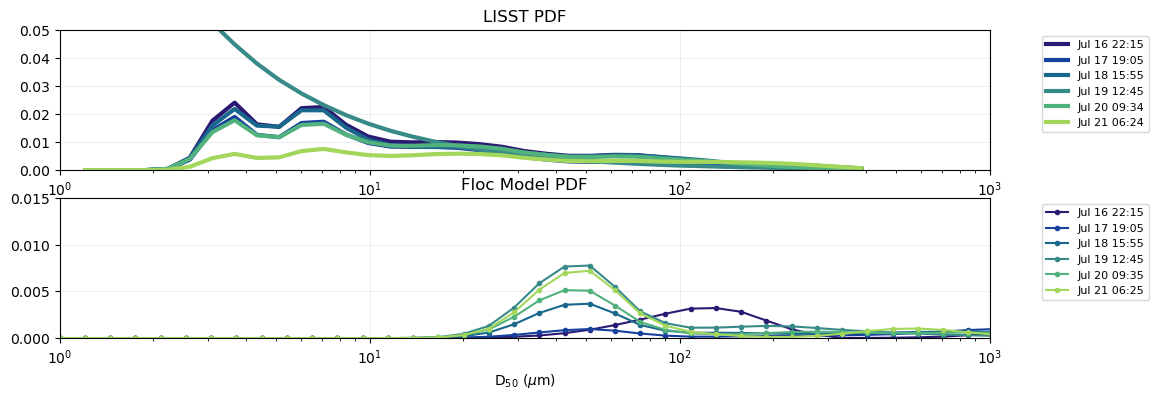

In [4]:
# Load in sediment data 
from scipy.integrate import cumulative_trapezoid #, trapz
import cmocean as cmo

model = xr.open_dataset("FlocMod_ADV_G_16.nc", decode_times=False)
Ds = model.Ds.values
nf = model.nf
date = pd.to_datetime("2020-07-16 20:10:01")

model = model.dropna(dim="N", how="any")
mtime = [date + pd.Timedelta(t, unit='s') for t in model.time.values]
nt = len(model.time) 



# LISST size classes // append last element
x = lds.size_class.values 
x = np.append(x, x[-1])


fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharey=False)

def date2color(date, cmap=cmo.cm.haline):
    d0 = pd.to_datetime(ldates[i])
    d1 = (d0 - mtime[-1]).total_seconds() 
    normalize = (d0 - date).total_seconds() / d1
    return cmo.cm.haline(normalize)


Ds_ = Ds*1e6        
for i in range(5, 300, 50):

    conc = model.ssc.isel(time=i)
    volume = model.Ds**3 * (model.Ds/10e-6)**model.nf.isel(time=i)
    conc = conc*volume/np.sum(volume*conc)
    conc = conc.mean(dim='N').values


    cdf_integrated = cumulative_trapezoid(conc, Ds_, initial=0)
    cdf = cdf_integrated / cdf_integrated[-1]   

    pdf = np.gradient(cdf, Ds_)
    print(np.trapezoid(pdf, Ds_))

    # 4. Plot the CDF against your x-axis (Ds)
    color = date2color(mtime[i]) 
    axs[1].plot(Ds_, pdf, '-o', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))

    ### Plot equivalent LISST data

    cdf = lds.CDF.sel(time=mtime[i], method='nearest').isel(depth=0)
    cdf = cdf.mean(dim='sample')

    pdf = np.gradient(cdf, x)
    d0 = pd.to_datetime(cdf.time.values)
    color = date2color(d0) 
    axs[0].plot(x, pdf, '-', color=color, linewidth=3, label=d0.strftime("%b %d %H:%M"))

axs[1].set_title("Floc Model PDF")
axs[0].set_title("LISST PDF")
axs[0].set_ylim(0, 0.05)   
axs[1].set_ylim(0, 0.015)   
for ax in axs:
    ax.set_xlim(1, 1000)
    
    ax.set_xlabel('D$_{50}$ ($\mu$m)')
    # ax.set_xlim(x[0], x[-1])
    ax.grid(alpha=0.2)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    ax.set_xscale('log')

<>:35: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:35: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1376862/4257198497.py:35: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_xlabel('D$_{50}$ ($\mu$m)')


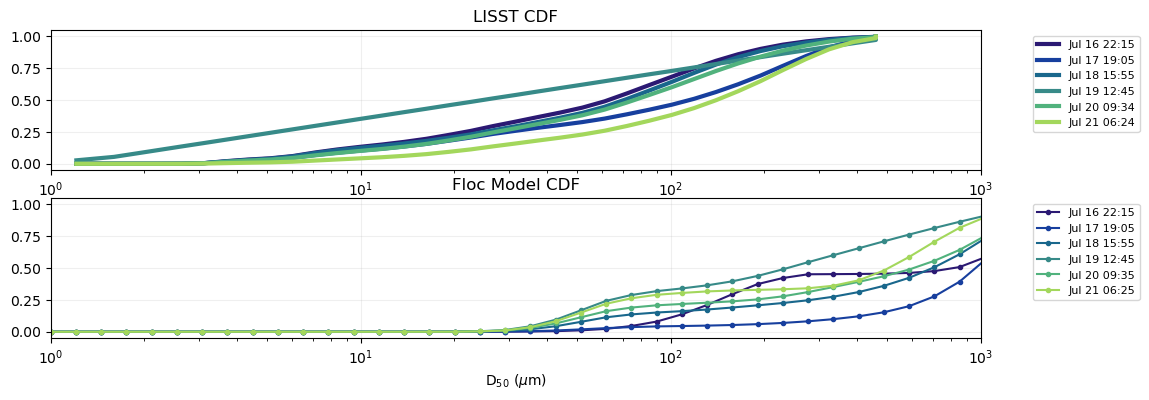

In [5]:
# CDF 

fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharey=False)
     
for i in range(5, 300, 50):

    conc = model.ssc.isel(time=i)
    volume = model.Ds**3 * (model.Ds/10e-6)**model.nf.isel(time=i)
    conc = conc*volume/np.sum(volume*conc)
    conc = conc.mean(dim='N').values


    cdf_integrated = cumulative_trapezoid(conc, Ds_, initial=0)
    cdf = cdf_integrated / cdf_integrated[-1]   

    # 4. Plot the CDF against your x-axis (Ds)
    color = date2color(mtime[i]) 
    axs[1].plot(Ds_, cdf, '-o', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))

    ### Plot equivalent LISST data

    cdf = lds.CDF.sel(time=mtime[i], method='nearest').isel(depth=0)
    cdf = cdf.mean(dim='sample')

    d0 = pd.to_datetime(cdf.time.values)
    color = date2color(d0) 
    axs[0].plot(x, cdf, '-', color=color, linewidth=3, label=d0.strftime("%b %d %H:%M"))

axs[1].set_title("Floc Model CDF")
axs[0].set_title("LISST CDF")

for ax in axs:
    ax.set_xlim(1, 1000)
    
    ax.set_xlabel('D$_{50}$ ($\mu$m)')
    # ax.set_xlim(x[0], x[-1])
    ax.grid(alpha=0.2)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    ax.set_xscale('log')

<>:34: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:40: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:34: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:40: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1376862/1283539751.py:34: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_xlabel('D$_{50}$ ($\mu$m)')
/tmp/ipykernel_1376862/1283539751.py:40: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A r

<xarray.DataArray 'vconc' (time: 3977, sample: 120, depth: 1, size_class: 36)> Size: 137MB
[17180640 values with dtype=float64]
Coordinates:
  * time        (time) datetime64[ms] 32kB 2020-07-16T20:10:00 ... 2020-07-30...
  * sample      (sample) int32 480B 1 2 3 4 5 6 7 ... 115 116 117 118 119 120
  * depth       (depth) float32 4B 3.5
  * size_class  (size_class) float32 144B 1.21 1.6 1.89 ... 324.0 386.0 459.0
Attributes:
    name:           vconc
    long_name:      VOLUME CONCENTRATION (UL/L)        
    units:          ul/l
    minimum:        0.0
    maximum:        4733.51
    serial_number:  2107
    valid_range:    [     0. 100000.]
<xarray.DataArray 'vconc' (time: 3977, sample: 120, depth: 1, size_class: 36)> Size: 137MB
[17180640 values with dtype=float64]
Coordinates:
  * time        (time) datetime64[ms] 32kB 2020-07-16T20:10:00 ... 2020-07-30...
  * sample      (sample) int32 480B 1 2 3 4 5 6 7 ... 115 116 117 118 119 120
  * depth       (depth) float32 4B 3.5
  * size_c

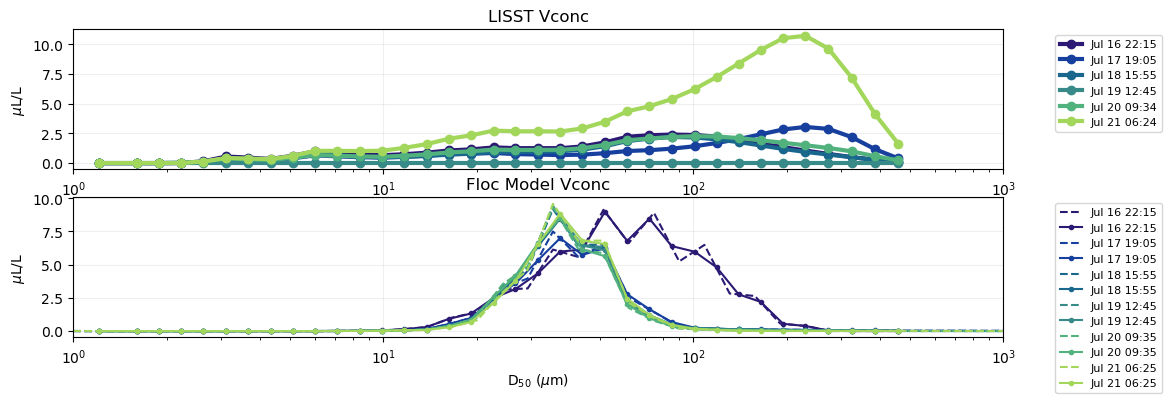

In [8]:
# volume concentration

fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharey=False)
     
for i in range(5, 300, 50):

    conc = model.ssc.isel(time=i)
    volume = 4/3 * np.pi * (model.Ds/2)**3 
    conc = conc*volume 
    conc = conc.mean(dim='N').values *1e10

    # 4. Plot the CDF against your x-axis (Ds)
    color = date2color(mtime[i]) 
    interpolated = np.interp(x[0:-1], Ds_, conc) 
    axs[1].plot(Ds_, conc, '--', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))
    axs[1].plot(x[0:-1], interpolated, '-o', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))

    # axs[1].plot(Ds_, conc, '-o', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))

    ### Plot equivalent LISST data
    cdf = lds.vconc.sel(time=mtime[i], method='nearest').isel(depth=0)
    cdf = cdf.mean(dim='sample')

    d0 = pd.to_datetime(cdf.time.values)
    color = date2color(d0) 
    axs[0].plot(x[0:-1], cdf, '-o', color=color, linewidth=3, label=d0.strftime("%b %d %H:%M"))

axs[1].set_title("Floc Model Vconc")
axs[0].set_title("LISST Vconc")

for ax in axs:
    ax.set_xlim(1, 1000)
    
    ax.set_xlabel('D$_{50}$ ($\mu$m)')
    # ax.set_xlim(x[0], x[-1])
    ax.grid(alpha=0.2)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    ax.set_xscale('log')
    ax.set_ylabel("$\mu$L/L")
    print(lds.vconc)

In [ ]:
# BUILD INTERPOLATION MATRIX X 

# volume concentration
I = 0 

DsL = x[0:-1]  # LISST size classes

if 0 :

    Nl = len(DsL)
    Nf = len(Ds_)
    H = np.zeros((Nl, Nf))

    for j in range(Nf):
        print("Sorting floc size class: ", Ds_[j])
        for i in range(Nl):
            if (Ds_[j] <= DsL[i]):
                print("-> placing in LISST size class: ", DsL[i])
                H[i, j] = volume[j]
                break
            if i==(Nl-1):
                print("Larger than max(LISST) -> placing in LISST size class: ", DsL[i])
                H[i, j] = volume[j]
                break

    print(H)

# Prep for saving everything 

variance = lds.vconc.var(dim='sample').isel(depth=0)
vconc = lds.vconc.mean(dim='sample').isel(depth=0)

# Theoretical "start date" for our simulation 
start_date = pd.to_datetime("2020-07-16 20:10:01")


time_in_seconds = (lds.time.values - np.datetime64(start_date)) / np.timedelta64(1, 's')

lisst_data = pd.DataFrame()
R = pd.DataFrame()

R['seconds'] = time_in_seconds.astype(int)
lisst_data['seconds'] = time_in_seconds.astype(int)

for i in range(len(DsL)):
    lisst_data[DsL[i]] = vconc.isel(size_class=i).values
    var_ = variance.isel(size_class=i).values
    var_[var_==0] = 1e-2
    R[DsL[i]] = var_

R = R[R['seconds'] >= 0]
lisst_data = lisst_data[lisst_data['seconds'] >= 0]

R.to_csv("lisst_variance.csv", index=False)
lisst_data.to_csv("lisst_data.csv", index=False)

assert(False)
conc = model.ssc.isel(time=i)
volume = 4/3 * np.pi * (model.Ds/2)**3 
conc = conc*volume 
conc = conc.mean(dim='N').values *1e10

# 4. Plot the CDF against your x-axis (Ds)
color = date2color(mtime[i]) 
interpolated = np.interp(x[0:-1], Ds_, conc) 
axs[1].plot(Ds_, conc, '--', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))
axs[1].plot(x[0:-1], interpolated, '-o', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))

# axs[1].plot(Ds_, conc, '-o', color=color, markersize=3, label=mtime[i].strftime("%b %d %H:%M"))

### Plot equivalent LISST data
cdf = lds.vconc.sel(time=mtime[i], method='nearest').isel(depth=0)
cdf = cdf.mean(dim='sample')

d0 = pd.to_datetime(cdf.time.values)
color = date2color(d0) 
axs[0].plot(x[0:-1], cdf, '-o', color=color, linewidth=3, label=d0.strftime("%b %d %H:%M"))

axs[1].set_title("Floc Model Vconc")
axs[0].set_title("LISST Vconc")

for ax in axs:
    ax.set_xlim(1, 1000)
    
    ax.set_xlabel('D$_{50}$ ($\mu$m)')
    # ax.set_xlim(x[0], x[-1])
    ax.grid(alpha=0.2)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    ax.set_xscale('log')
    ax.set_ylabel("$\mu$L/L")
    print(lds.vconc)

<>:85: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:91: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:85: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:91: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1376862/1047482707.py:85: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_xlabel('D$_{50}$ ($\mu$m)')
/tmp/ipykernel_1376862/1047482707.py:91: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A r

      seconds  1.21  1.6  1.89      2.23      2.63      3.11      3.67  \
0          -1   0.0  0.0   0.0  0.007359  0.097698  0.362273  0.309040   
1         299   0.0  0.0   0.0  0.007200  0.098776  0.373685  0.319401   
2         598   0.0  0.0   0.0  0.007434  0.101925  0.384038  0.325140   
3         899   0.0  0.0   0.0  0.007418  0.102664  0.388436  0.329048   
4        1198   0.0  0.0   0.0  0.007776  0.105302  0.393269  0.332550   
...       ...   ...  ...   ...       ...       ...       ...       ...   
3972  1191599   0.0  0.0   0.0  0.000000  0.000000  0.000000  0.000000   
3973  1191898   0.0  0.0   0.0  0.000000  0.000000  0.000000  0.000000   
3974  1192199   0.0  0.0   0.0  0.000000  0.000000  0.000000  0.000000   
3975  1192498   0.0  0.0   0.0  0.000000  0.000000  0.000000  0.000000   
3976  1192799   0.0  0.0   0.0  0.000000  0.000000  0.000000  0.000000   

          4.33      5.11  ...     101.0     119.0     140.0     165.0  \
0     0.247409  0.449909  ...  1.59790

/tmp/ipykernel_1376862/1047482707.py:85: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_xlabel('D$_{50}$ ($\mu$m)')
/tmp/ipykernel_1376862/1047482707.py:91: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_ylabel("$\mu$L/L")


AssertionError: 

<>:39: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:39: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1505426/2883341849.py:39: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_ylabel('D$_{50}$ ($\mu$m)')


<xarray.Dataset> Size: 229MB
Dimensions:     (time: 3977, sample: 120, depth: 1, size_class: 36, CDF: 37,
                 lat: 1, lon: 1)
Coordinates:
  * time        (time) int32 16kB 2459047 2459047 2459047 ... 2459061 2459061
  * sample      (sample) int32 480B 1 2 3 4 5 6 7 ... 115 116 117 118 119 120
  * depth       (depth) float32 4B 3.5
  * size_class  (size_class) float32 144B 1.21 1.6 1.89 ... 324.0 386.0 459.0
    CDF         (time, sample, depth, CDF) float32 71MB ...
  * lat         (lat) float32 4B 37.55
  * lon         (lon) float32 4B -122.2
Data variables: (12/13)
    time2       (time) int32 16kB 72600000 72900000 ... 55499999 55800000
    vconc       (time, sample, depth, size_class) float64 137MB ...
    ltrans      (time, sample, depth) float32 2MB ...
    batt        (time, sample, depth) float32 2MB ...
    lref        (time, sample, depth) float32 2MB ...
    ptrans      (time, sample, depth) float32 2MB ...
    ...          ...
    T_20        (time, sample, de

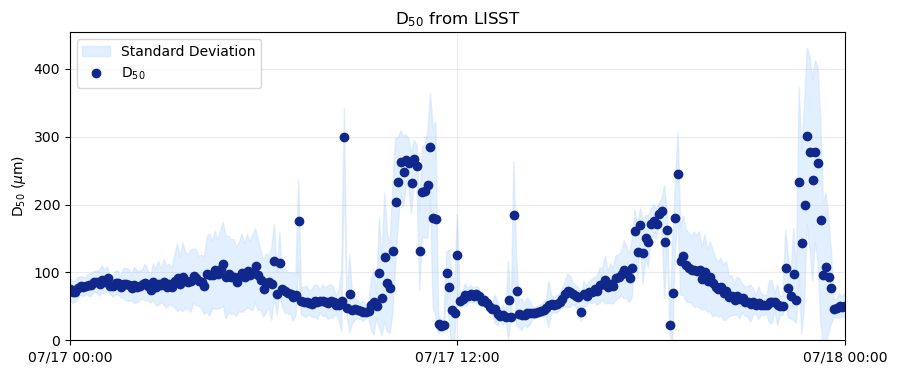

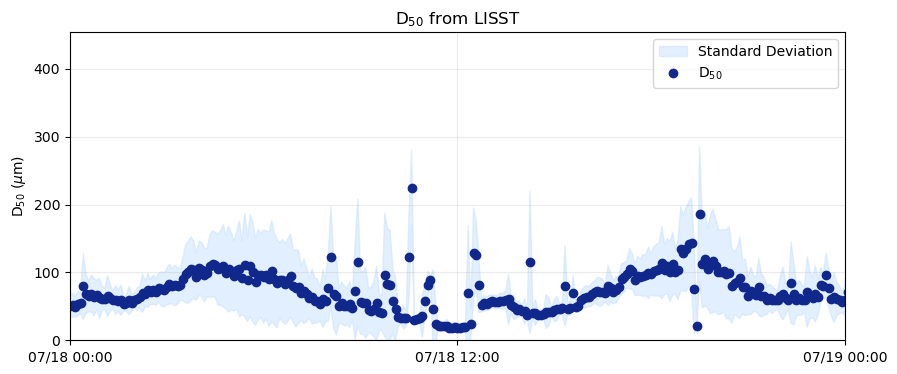

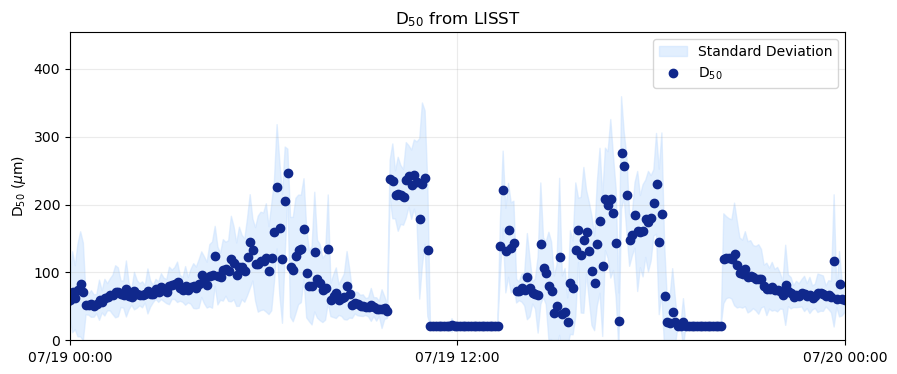

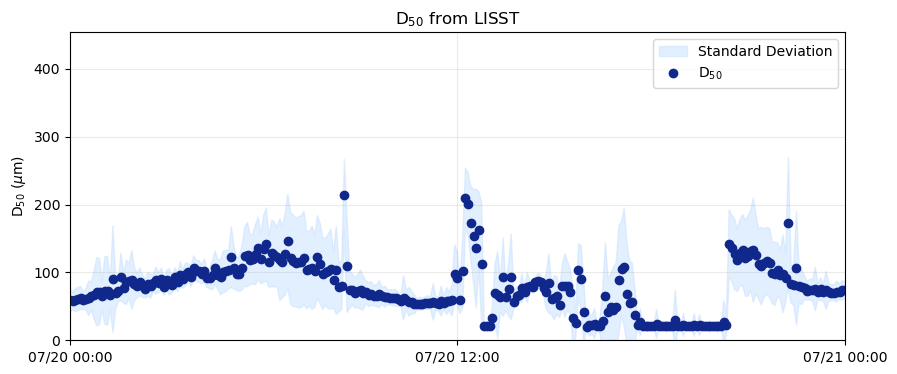

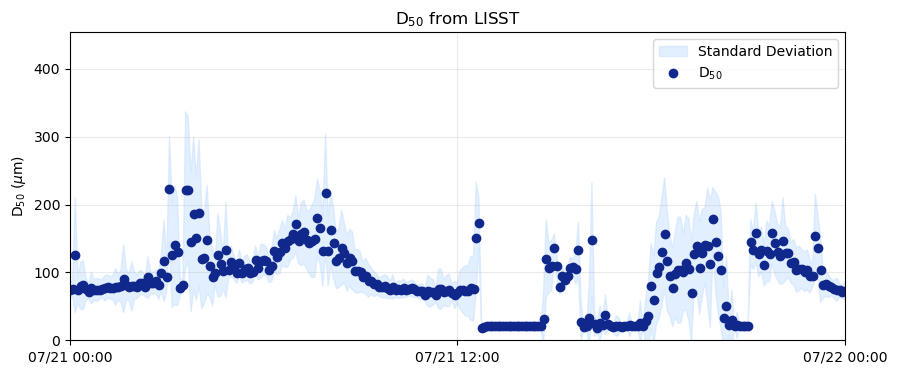

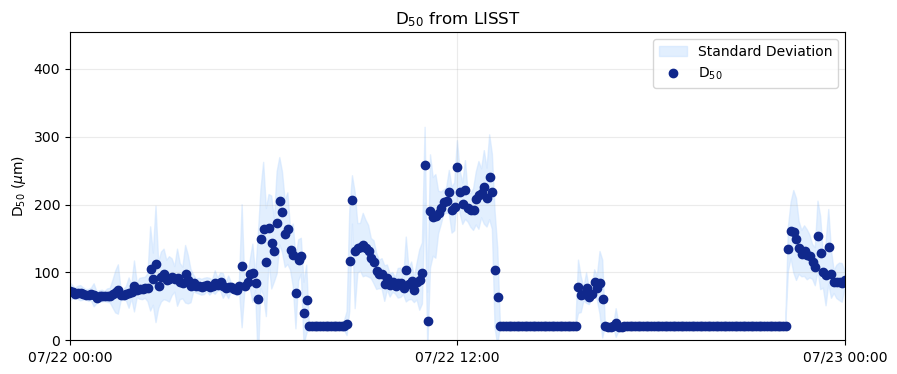

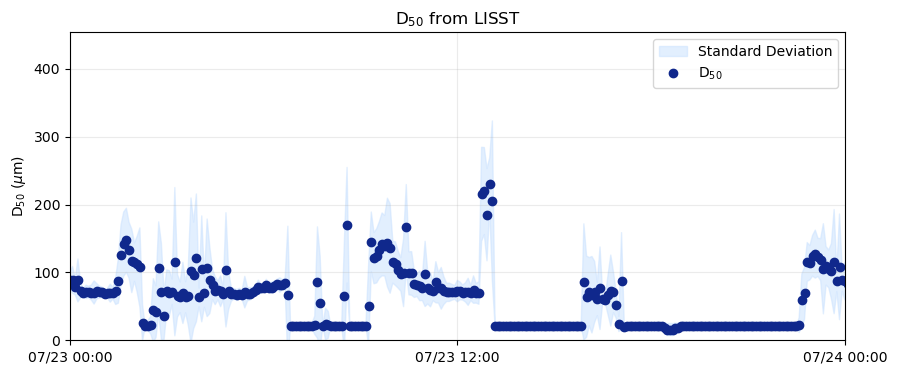

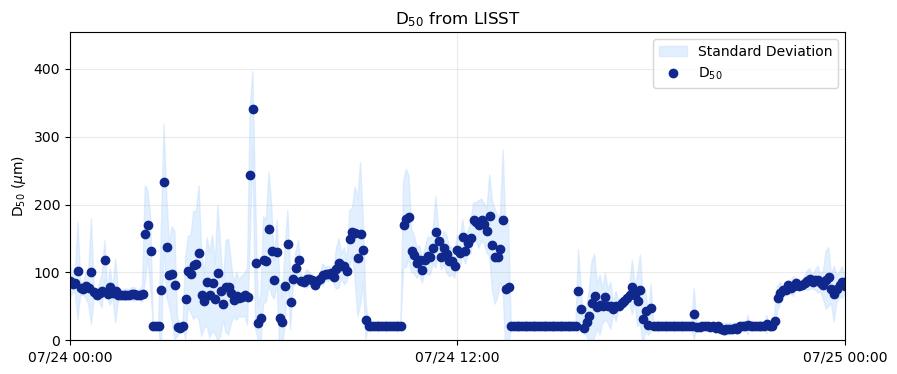

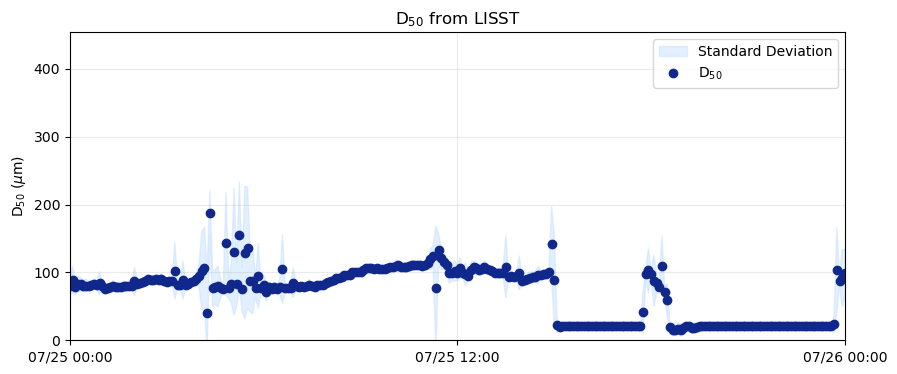

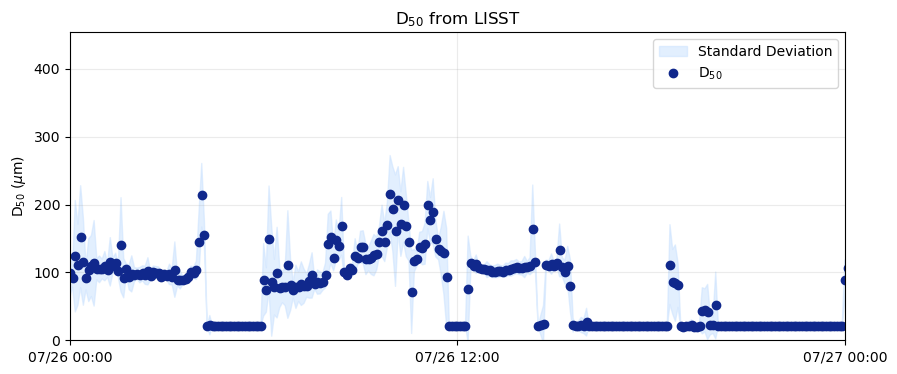

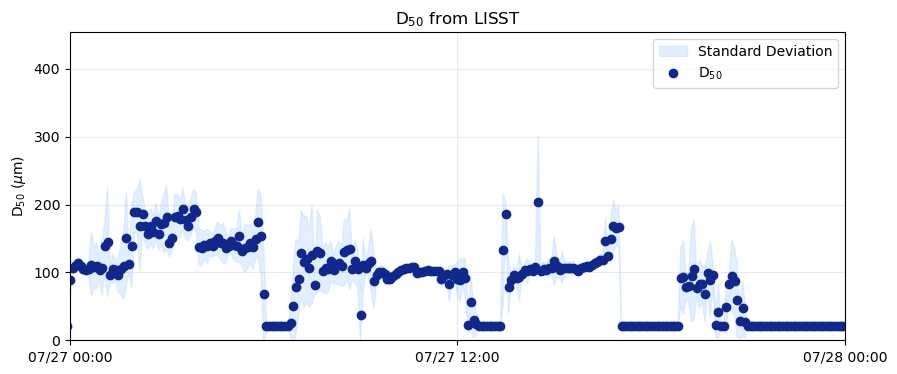

In [ ]:


lds = lds.isel(depth=0)



stds = lds['D50'].std(axis=1) 
d50 = lds['D50'].mean(axis=1)


# assert(False)

for d in range(17, 28):

    fig = plt.figure(figsize=(10,4))
    ax = plt.gca()

    ax.fill_between(ldates, np.squeeze(d50-stds), np.squeeze(d50+stds), color='#CBE2FE', alpha=0.55, label="Standard Deviation")

    ax.plot(ldates, d50, 'o', color='#10288C', label="D$_{50}$")
    # fill between

    ax.grid(alpha=0.25)
    ax.set_ylabel('D$_{50}$ ($\mu$m)')
    ax.set_ylim(0,)
    ax.set_title('D$_{50}$ from LISST')
    format_date_ax(ax, 12)
    ax.set_xlim(pd.to_datetime('2020-07-%d' % d), pd.to_datetime('2020-07-%d' % (d+1)))
    ax.legend()

#### 


In [ ]:
# Load in ADCP data
adcp = xr.open_dataset("/global/homes/s/siennaw/scratch/siennaw/data/usgs/resampled_adcp_usgs.nc") #, decode_times=False)

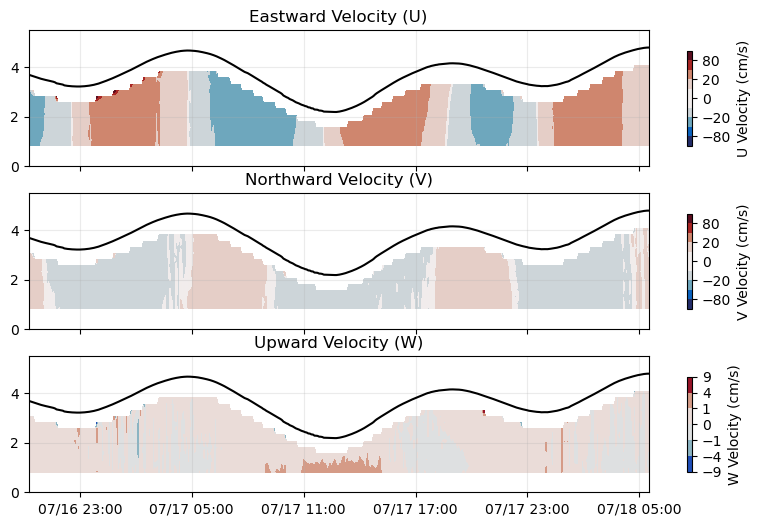

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

low, high = 0, 400
rtime = adcp.time.values[low:high]

offset= 3.537306921274909


axs[0].set_xlim(rtime[0], rtime[-1])
levels = [-100, -80, -50, -20, -1, 0, 1, 20, 50, 80, 100]

velocity = np.squeeze(adcp.u_1205)
z = adcp.depth.values
h = axs[0].contourf(rtime, -z + offset, velocity[low:high,:].T, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='U Velocity (cm/s)', shrink=0.7)
axs[0].set_title('Eastward Velocity (U)')

def format_date_ax(ax, int=1):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=int))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)


depths =  np.squeeze(adcp.P_1.values[low:high]) #+ 0.41

axs[0].plot(rtime, depths, color='k', label='Depth')
axs[1].plot(rtime, depths, color='k', label='Depth')
axs[2].plot(rtime, depths, color='k', label='Depth')

velocity = np.squeeze(adcp.v_1206)
h = axs[1].contourf(rtime, -z + offset, velocity[low:high,:].T,  cmap=cmo.cm.balance, levels=levels)

plt.colorbar(h, label='V Velocity (cm/s)', shrink=0.7)
axs[1].set_title('Northward Velocity (V)')

vmin, vmax = -10, 10
velocity = np.squeeze(adcp.w_1204)

levels = [-9, -4, -1, 0, 1, 4, 9]
h = axs[2].contourf(rtime, -z + offset, velocity[low:high,:].T, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='W Velocity (cm/s)', shrink=0.7)
axs[2].set_title('Upward Velocity (W)')

for ax in axs:
    ax.grid(alpha=0.25)
    format_date_ax(ax, int=6)
    ax.set_ylim(0, 5.5)


NameError: name 'adcp' is not defined

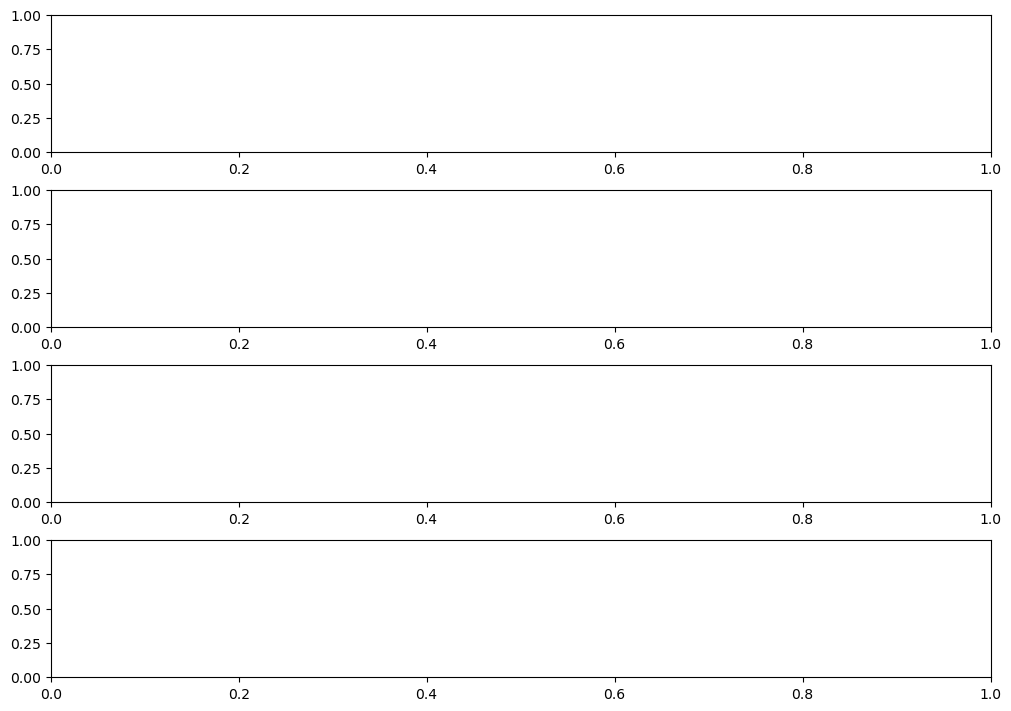

In [ ]:
fig, axs = plt.subplots(4, 1, figsize=(10, 7), sharex=False, constrained_layout=True)

low, high = 0, 900
rtime = adcp.time.values[low:high]

#                                 # blanking distance         
depths =  np.squeeze(adcp.P_1.values[low:high])  

levels = [-100, -80, -50, -20, -1, 0, 1, 20, 50, 80, 100]

velocity = np.squeeze(adcp.u_1205)
velocity = velocity[low:high,:].T
z = adcp.depth.values
h = axs[1].contourf(rtime, offset-z, velocity, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='U Velocity (cm/s)', shrink=0.7)
axs[1].set_title('ADCP (u, eastward)')


velocity = np.squeeze(adcp.w_1204)
levelsW = [-4, -1, -0.5, 0, 0.5, 1, 4]
h = axs[0].contourf(rtime, offset-z, velocity[low:high,:].T, cmap=cmo.cm.balance, levels=levelsW)
plt.colorbar(h, label='w (cm/s)', shrink=0.7)
axs[0].set_title('ADCP (w, upward)')


model_time = [pd.to_datetime(rtime[0]) + pd.Timedelta(seconds=j) for j in ds.time.values]

axs[2].set_title("Modeled U Velocity (eastward)")
h = axs[2].contourf(model_time, 4-ds.z, ds.U.T*100, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='U Velocity (cm/s)', shrink=0.7)

axs[3].set_title("Modeled shear")
shear = np.sqrt((ds.Q2 /ds.Kz)) 
ax2 = axs[3].twinx()
ax2.plot(model_time, shear.sel(z=0.1, method='nearest').values, '--', color='b', label='modeled shear @ 0.2 m')
ax2.set_ylim(0, 2)

adv_shear = adv.shear.dropna()
ax2.plot(adv_shear/10, color='r', label='ADV Shear')
ax2.legend()
h = axs[3].pcolormesh(model_time, 4-ds.z, shear.T, cmap=cmo.cm.rain, vmin=0, vmax=2)
ax2.set_ylabel('shear (1/s)')
# h = axs[3].pcolormesh(model_time, 4-ds.z, ds.C.T, cmap=cmo.cm.rain, vmin=20, vmax=25)

# h = axs[3].pcolormesh(model_time, ds.z, np.log(ds.Q2.T), cmap=cmo.cm.rain, vmin=-8, vmax=-2)
plt.colorbar(h, label='shear (1/s)', shrink=0.7)

for ax in axs:
    ax.plot(rtime, depths, color='k', label='Depth')
    ax.grid(alpha=0.25)
    format_date_ax(ax, int=12)
    ax.set_xlim(rtime[0], rtime[-1])
    ax.set_ylim(0, 10)
    ax.set_ylabel('Depth (m)')
# plt.tight_layout()

